# TAO ADCP Velocity Climatology (1993–2012)
#
# Loads daily TAO mooring data at 0°N: 170°W, 140°W, 110°W,
# computes monthly-mean and monthly-std velocity profiles (m/s),
# and saves one NetCDF per location to tao_data/.

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cmo

In [2]:
# Location labels and their longitude values (°E)
tao_locs = [
    ('170W', 190.),
    ('140W', 220.),
    ('110W', 250.),
]

for loc_label, lon_val in tao_locs:
    ds = xr.open_dataset(f'tao_data/TAO_{loc_label}_1993to2012.cdf')

    # xarray auto-masks fill value (1e+35); QU=2 → good data, QU=0 → missing
    # Convert cm/s → m/s; squeeze lat/lon singleton dims
    u = (ds.u_1205 / 100.0).squeeze(('lat', 'lon'))   # (time, depth)
    v = (ds.v_1206 / 100.0).squeeze(('lat', 'lon'))

    u_mean = u.groupby('time.month').mean('time')      # (month, depth)
    u_std  = u.groupby('time.month').std('time')
    v_mean = v.groupby('time.month').mean('time')
    v_std  = v.groupby('time.month').std('time')

    ds_clim = xr.Dataset(
        {'u_mean': u_mean, 'u_std': u_std,
         'v_mean': v_mean, 'v_std': v_std},
        attrs={
            'lon_degE': lon_val,
            'lat': 0.0,
            'units': 'm/s',
            'source': f'TAO ADCP 0N {loc_label}, daily 1993-01-01 to 2012-12-31',
        }
    )

    out_path = f'tao_data/tao_clim_{loc_label}_1993to2012.nc'
    ds_clim.to_netcdf(out_path)
    print(f'Saved {out_path}  depth: {float(ds.depth[0]):.0f}–{float(ds.depth[-1]):.0f} m  '
          f'valid U fraction: {float(u.notnull().mean()):.2%}')

Saved tao_data/tao_clim_170W_1993to2012.nc  depth: 10–475 m  valid U fraction: 45.48%


Saved tao_data/tao_clim_140W_1993to2012.nc  depth: 10–425 m  valid U fraction: 54.99%


Saved tao_data/tao_clim_110W_1993to2012.nc  depth: 10–375 m  valid U fraction: 49.03%


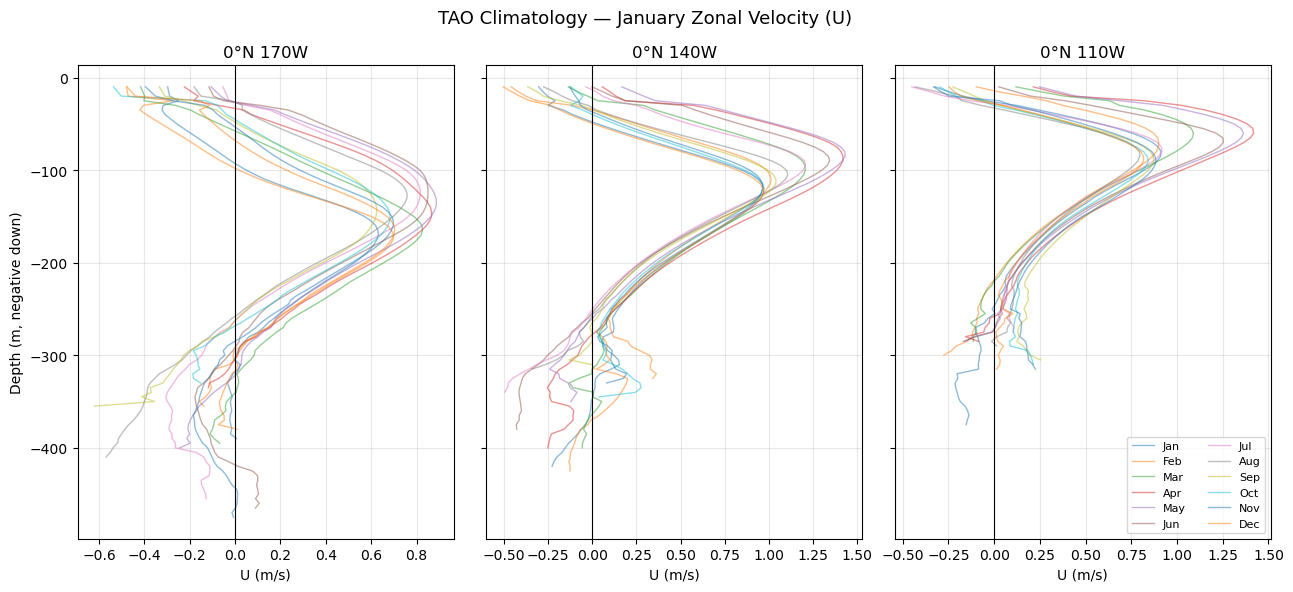

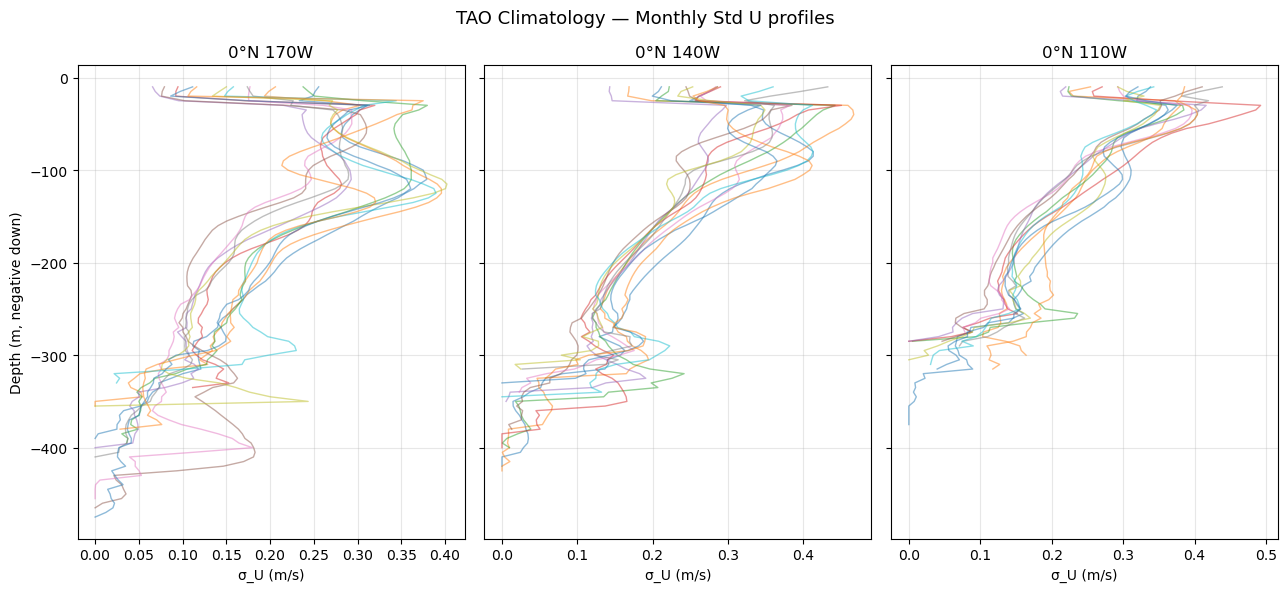

In [3]:
# Verification: plot mean U and std U profiles for month 1 (January) at each location
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(13, 6), sharey=True)
fig.suptitle('TAO Climatology — January Zonal Velocity (U)', fontsize=13)

for ax, (loc_label, lon_val) in zip(axes, tao_locs):
    ds_c = xr.open_dataset(f'tao_data/tao_clim_{loc_label}_1993to2012.nc')
    depth = ds_c.depth.values

    for m_idx, m_name in enumerate(month_names):
        u_mn = ds_c.u_mean.sel(month=m_idx+1).values
        ax.plot(u_mn, -depth, alpha=0.5, lw=1, label=m_name)

    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('U (m/s)')
    ax.set_title(f'0°N {loc_label}')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Depth (m, negative down)')
axes[-1].legend(fontsize=8, loc='lower right', ncol=2)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(13, 6), sharey=True)
fig2.suptitle('TAO Climatology — Monthly Std U profiles', fontsize=13)

for ax, (loc_label, lon_val) in zip(axes2, tao_locs):
    ds_c = xr.open_dataset(f'tao_data/tao_clim_{loc_label}_1993to2012.nc')
    depth = ds_c.depth.values

    for m_idx, m_name in enumerate(month_names):
        u_std = ds_c.u_std.sel(month=m_idx+1).values
        ax.plot(u_std, -depth, alpha=0.5, lw=1)

    ax.set_xlabel('σ_U (m/s)')
    ax.set_title(f'0°N {loc_label}')
    ax.grid(alpha=0.3)

axes2[0].set_ylabel('Depth (m, negative down)')
plt.tight_layout()
plt.show()